In [5]:
import sparse
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import uproot
import polars as pl
import awkward as ak

In [2]:
ospool_sparse_srm_filename = "job_14965616_stacked_sparse_5d_srm.h5"
ospool_sparse_srm_dir = Path("../")
with h5py.File(ospool_sparse_srm_dir / ospool_sparse_srm_filename, "r") as f:
    ospool_sparse_srm = sparse.COO(
        f['srm/coords'][:], # type: ignore
        f['srm/data'][:], # type: ignore
        shape=tuple(f['srm'].attrs['shape']) # type: ignore
    )

In [87]:
root_file_path = "pixel_singles_a_local_j_0.root"
# 1. Scan for valid trees

energy_min = 0.14 * 0.995
energy_max = 0.14 * 1.005

branches = [
    "TotalEnergyDeposit",
    "PreStepUniqueVolumeID",
    "EventPosition_X",
    "EventPosition_Y",
    "EventPosition_Z"
]
singles_crystal_ids = np.array([], dtype=np.int32)
singles_pixel_ids = np.array([], dtype=np.int32)
singles_event_positions = np.empty((0, 3), dtype=np.float32)
with uproot.open(root_file_path) as root_file:
    tree_names = [
        name
        for name, class_name in root_file.classnames(cycle=False).items()
        if class_name == "TTree"
    ]
    for tree_name in tree_names:
        tree = root_file[tree_name]
        data = tree.arrays(branches, library="np")
        df = pl.DataFrame(data).with_columns(
            pl.col("PreStepUniqueVolumeID")
            .str.split("_")
            .list.get(-1)
            .cast(pl.Int32)
            .alias("PixelID"),
            pl.col("PreStepUniqueVolumeID")
            .str.split("_")
            .list.get(1)
            .cast(pl.Int32)
            .alias("CrystalID"),
        )
        df = df.filter(
            (pl.col("TotalEnergyDeposit") >= energy_min)
            & (pl.col("TotalEnergyDeposit") <= energy_max)
        )
        # print(df.columns)
        if df.is_empty():
            continue
        local_singles_crystal_ids = df["CrystalID"].to_numpy().astype(np.int32)
        local_singles_pixel_ids = df["PixelID"].to_numpy().astype(np.int32)
        local_singles_event_positions = df.select(pl.col("EventPosition_X"), pl.col("EventPosition_Y"), pl.col("EventPosition_Z")).to_numpy()
        print(f"Tree {tree_name}: {len(local_singles_crystal_ids)} singles events found.")
        singles_crystal_ids = np.concatenate(
            [singles_crystal_ids, df["CrystalID"].to_numpy().astype(np.int32)]
        )
        singles_pixel_ids = np.concatenate(
            [singles_pixel_ids, df["PixelID"].to_numpy().astype(np.int32)]
        )
        singles_event_positions = np.concatenate(
            [singles_event_positions, local_singles_event_positions]
        )

print(f"Singles crystal IDs shape: {singles_crystal_ids.shape}")
print(f"Singles pixel IDs shape: {singles_pixel_ids.shape}")
print(f"Singles event positions shape: {singles_event_positions.shape}")

Tree Pixel_1_Singles: 2826 singles events found.
Tree Pixel_2_Singles: 3177 singles events found.
Tree Pixel_3_Singles: 3755 singles events found.
Tree Pixel_4_Singles: 4484 singles events found.
Tree Pixel_5_Singles: 5288 singles events found.
Tree Pixel_6_Singles: 6013 singles events found.
Tree Pixel_7_Singles: 6581 singles events found.
Tree Pixel_8_Singles: 7035 singles events found.
Tree Pixel_9_Singles: 6754 singles events found.
Tree Pixel_10_Singles: 6124 singles events found.
Tree Pixel_11_Singles: 5470 singles events found.
Tree Pixel_12_Singles: 4910 singles events found.
Tree Pixel_13_Singles: 4435 singles events found.
Tree Pixel_14_Singles: 3982 singles events found.
Tree Pixel_15_Singles: 3841 singles events found.
Tree Pixel_16_Singles: 3460 singles events found.
Tree Pixel_17_Singles: 3594 singles events found.
Tree Pixel_18_Singles: 3488 singles events found.
Tree Pixel_19_Singles: 3489 singles events found.
Tree Pixel_20_Singles: 3435 singles events found.
Tree Pixe

In [16]:
# Get min and max of crystal IDs and pixel IDs
min_crystal_id = np.min(singles_crystal_ids)
max_crystal_id = np.max(singles_crystal_ids)
min_pixel_id = np.min(singles_pixel_ids)
max_pixel_id = np.max(singles_pixel_ids)
# print them
print(f"Min crystal ID: {min_crystal_id}, Max crystal ID: {max_crystal_id}")
print(f"Min pixel ID: {min_pixel_id}, Max pixel ID: {max_pixel_id}")

Min crystal ID: 1, Max crystal ID: 80
Min pixel ID: 0, Max pixel ID: 624


In [20]:
print("Shape of the sparse system matrix:", ospool_sparse_srm.shape)

Shape of the sparse system matrix: (80, 625, 80, 80, 80)


In [18]:
# create 2d histogram on crystal_id and pixel_id
hist_shape = (80, 625)
linear_indices = (singles_crystal_ids-1) * 625 + singles_pixel_ids
counts_1d = np.bincount(linear_indices, minlength=80 * 625)
counts_2d = counts_1d.reshape(hist_shape)
print(f"Counts 1D shape: {counts_1d.shape}")

Counts 1D shape: (50000,)


In [19]:
from mlem_sparse.io import SparseSRM_IO_Manager, MeasurementMat_IO_Manager
from mlem_sparse.reconstruct import SparseMLEMReconstructor
from pathlib import Path
# Load the system matrix
srm_io_mgr = SparseSRM_IO_Manager()

In [21]:
srm_scipy = srm_io_mgr.get_combined_srm()
print("Shape of the sparse system matrix:", srm_scipy.shape)

Loading SRM heads:   0%|          | 0/80 [00:00<?, ?head/s]

Shape of the sparse system matrix: (50000, 1000000)


In [24]:
ospool_sparse_srm_reshaped = ospool_sparse_srm.reshape((80 * 625, 80 **3))
scipy_coo = ospool_sparse_srm_reshaped.to_scipy_sparse()
scipy_csr = scipy_coo.tocsr()

In [22]:
import torch

In [26]:
sparse_mlem_reconstructor_gpu = SparseMLEMReconstructor(
    scipy_csr,
    counts_1d,
    device=torch.device("cuda"),
)

Memory check passed!Transpose requires ~2.63 GB.
Available CUDA memory: 4.87 GB.
Computing explicit transpose matrix...


In [27]:
iters = [1, 3, 5, 10, 20, 30, 40, 50, 70, 100, 200]
estimate_vol_sparse_mlem_tensor_from_gpu = sparse_mlem_reconstructor_gpu.reconstruct(
    iterations=iters
)
estimate_data_np_from_gpu = np.array(
    [
        gpu_tensor.detach().cpu().numpy()
        for gpu_tensor in estimate_vol_sparse_mlem_tensor_from_gpu
    ]
)
del estimate_vol_sparse_mlem_tensor_from_gpu

MLEM Iteration:   0%|          | 0/200 [00:00<?, ?it/s]

In [28]:
from mlem_sparse.visualize import plot_volume_img_three_view

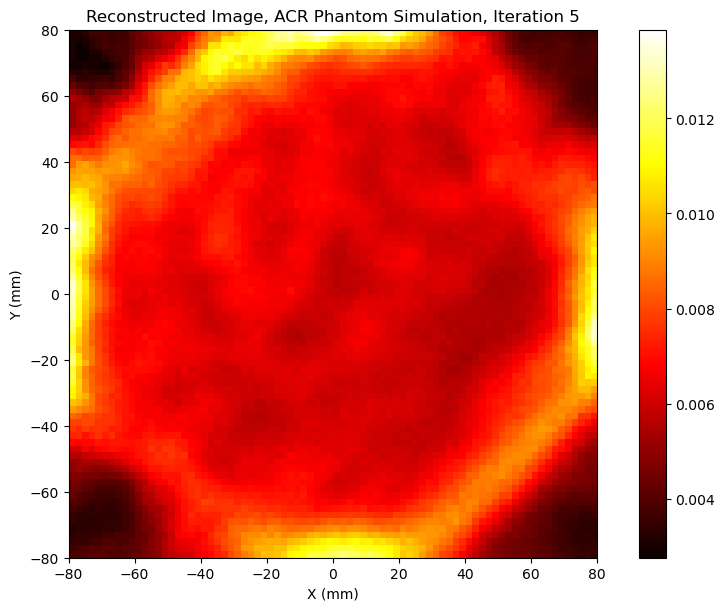

In [81]:
iter_id = 2

img_shape = (80, 80, 80)
fov_dim_mm = (160.0, 160.0, 160.0)
xy_extent = (
    -fov_dim_mm[0] * 0.5,
    fov_dim_mm[0] * 0.5,
    -fov_dim_mm[1] * 0.5,
    fov_dim_mm[1] * 0.5,
)

output_dir = Path("reconstructed_images_acr_phantom_ospool_srm")
output_dir.mkdir(exist_ok=True)

estimate_iter = estimate_data_np_from_gpu[iter_id]
estimate_iter = estimate_iter.reshape(img_shape)
img = estimate_iter[:, :, 60:80].sum(axis=2)
fig, ax = plt.subplots(1, 1, figsize=(8, 6),layout="constrained")
im = ax.imshow(img.T, cmap="hot", origin="lower", extent=xy_extent, aspect="equal",interpolation="none")
ax.set_title(
    f"Reconstructed Image, ACR Phantom Simulation, Iteration {iters[iter_id]}"
)
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
plt.colorbar(im, ax=ax)


In [108]:
iter_id = 8

img_shape = (80, 80, 80)
fov_dim_mm = (160.0, 160.0, 160.0)
xy_extent = (
    -fov_dim_mm[0] * 0.5,
    fov_dim_mm[0] * 0.5,
    -fov_dim_mm[1] * 0.5,
    fov_dim_mm[1] * 0.5,
)

output_dir = Path("reconstructed_images_acr_phantom_ospool_srm")
output_dir.mkdir(exist_ok=True)
for iter_id in range(len(iters)):
    estimate_iter = estimate_data_np_from_gpu[iter_id]
    estimate_iter = estimate_iter.reshape(img_shape)
    img = estimate_iter[:, :, 60:62].sum(axis=2)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6),layout="constrained")
    im = ax.imshow(img.T, cmap="hot", origin="lower", extent=xy_extent, aspect="equal",interpolation="none")
    ax.set_title(
        f"Reconstructed Image, ACR Phantom Simulation, Iteration {iters[iter_id]}"
    )
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    plt.colorbar(im, ax=ax)
    fig.savefig(output_dir / f"reconstructed_image_acr_phantom_iter_{iters[iter_id]}.png", dpi=300)
    plt.close(fig)


In [88]:
event_position_hist, postion_edges = np.histogramdd(
    singles_event_positions, bins=(80, 80, 80), range=((-80, 80), (-80, 80), (-80, 80))
)

In [89]:
print(f"event_position_hist shape: {event_position_hist.shape}")

event_position_hist shape: (80, 80, 80)


Text(0, 0.5, 'Y (mm)')

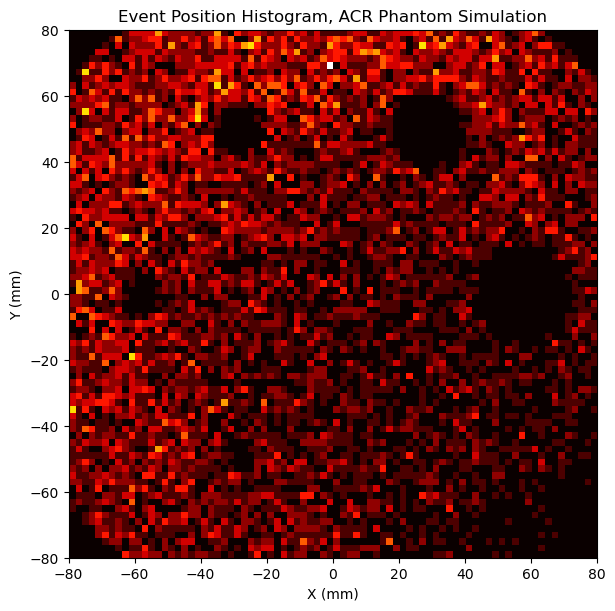

In [115]:
# Plot the event position histogram
fig, ax = plt.subplots(1, 1, figsize=(8, 6),layout="constrained")
im = ax.imshow(event_position_hist[:, :, 60:62].sum(axis=2).T, cmap="hot", origin="lower", extent=xy_extent, aspect="equal",interpolation="none")
ax.set_title(
    f"Event Position Histogram, ACR Phantom Simulation"
)
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")

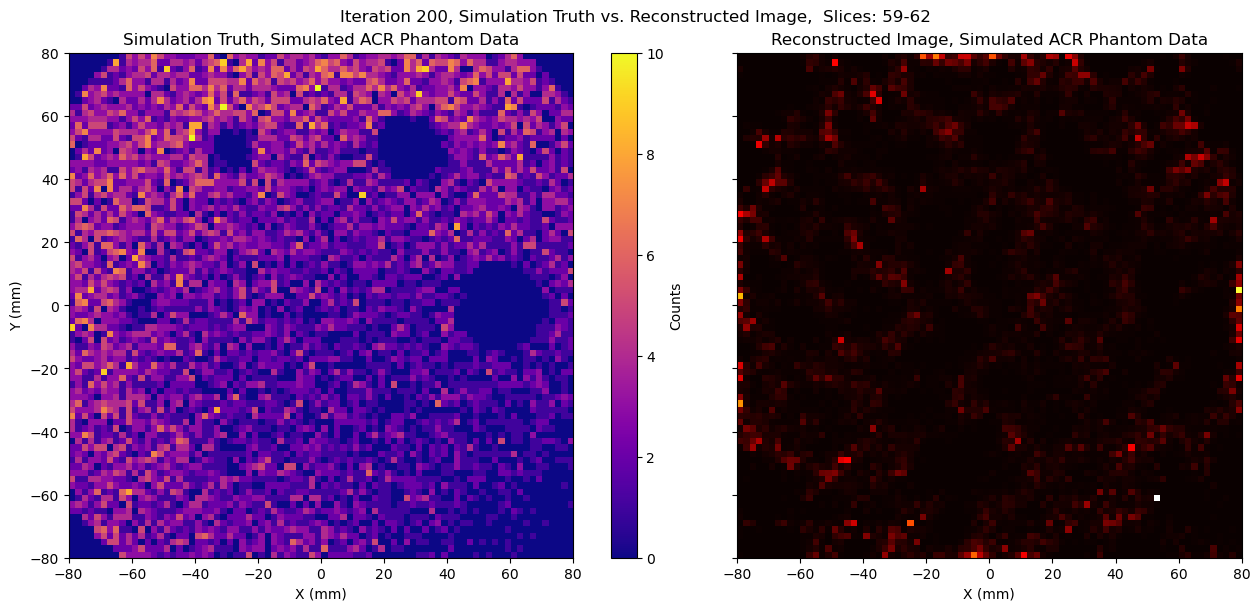

In [129]:
# Plot the simualtion truth with the same slice as the reconstructed image

slices = (59, 62)
outdir = Path("plot_simulation_vs_recon")
outdir.mkdir(exist_ok=True)
# 1. Pre-compute the simulation truth (it doesn't change inside the loop)
truth_img = event_position_hist[:, :, slices[0]:slices[1]].sum(axis=2).T

# 2. Turn on interactive mode
plt.ion()

# 3. Create the figure and axes ONCE outside the loop
fig, axes = plt.subplots(1, 2, figsize=(13, 6), layout="constrained",sharey=True)
title_text = fig.suptitle("") # Create an empty title object to update later

# 4. Initialize the static Simulation Truth plot
axes[0].imshow(truth_img, cmap="plasma", origin="lower", extent=xy_extent, aspect="equal", interpolation="none")
axes[0].set_title("Simulation Truth, Simulated ACR Phantom Data")
axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")
plt.colorbar(axes[0].images[0], ax=axes[0], label="Counts")


# 5. Initialize the Reconstructed plot with the first frame (or zeros)
initial_recon = estimate_data_np_from_gpu[0].reshape(img_shape)[:, :, slices[0]:slices[1]].sum(axis=2).T
im_recon = axes[1].imshow(initial_recon, cmap="hot", origin="lower", extent=xy_extent, aspect="equal", interpolation="none")
axes[1].set_title("Reconstructed Image, Simulated ACR Phantom Data")
axes[1].set_xlabel("X (mm)")
# axes[1].set_ylabel("Y (mm)")


# 6. Run the loop
for iter_id in range(len(iters)):
    recon_img = estimate_data_np_from_gpu[iter_id].reshape(img_shape)[:, :, slices[0]:slices[1]].sum(axis=2).T
    
    im_recon.set_data(recon_img)

    im_recon.set_clim(vmin=recon_img.min(), vmax=recon_img.max())

    title_text.set_text(f"Iteration {iters[iter_id]}, Simulation Truth vs. Reconstructed Image,  Slices: {slices[0]}-{slices[1]}")
    
    fig.savefig(outdir / f"iter_{iters[iter_id]}_slices_{slices[0]}_{slices[1]}.png", dpi=300, bbox_inches="tight")

    fig.canvas.draw()
    fig.canvas.flush_events()

plt.ioff()
plt.show()

plt.close("all")
